# Plaquette

Four-site plaquette cluster with Kanamori interaction.

In [1]:
import sys
sys.path.append('../common')
from model import *
from analysis import load_all_results, compute_sigma, deviation_table, \
    plot_iw_comparison, plot_w_comparison, plot_static_obs_table, plot_chi_contour

In [2]:
data = load_all_results()
block_lst = list(data[next(iter(data))]['G'].indices) if data else []

## 1. Single-Particle Green Function $G(i\omega_n)$


  G max-norm deviations:
              atomdiag     ctint   edipack
    atomdiag            1.62e-03  7.63e-10
       ctint                      1.62e-03
     edipack                              


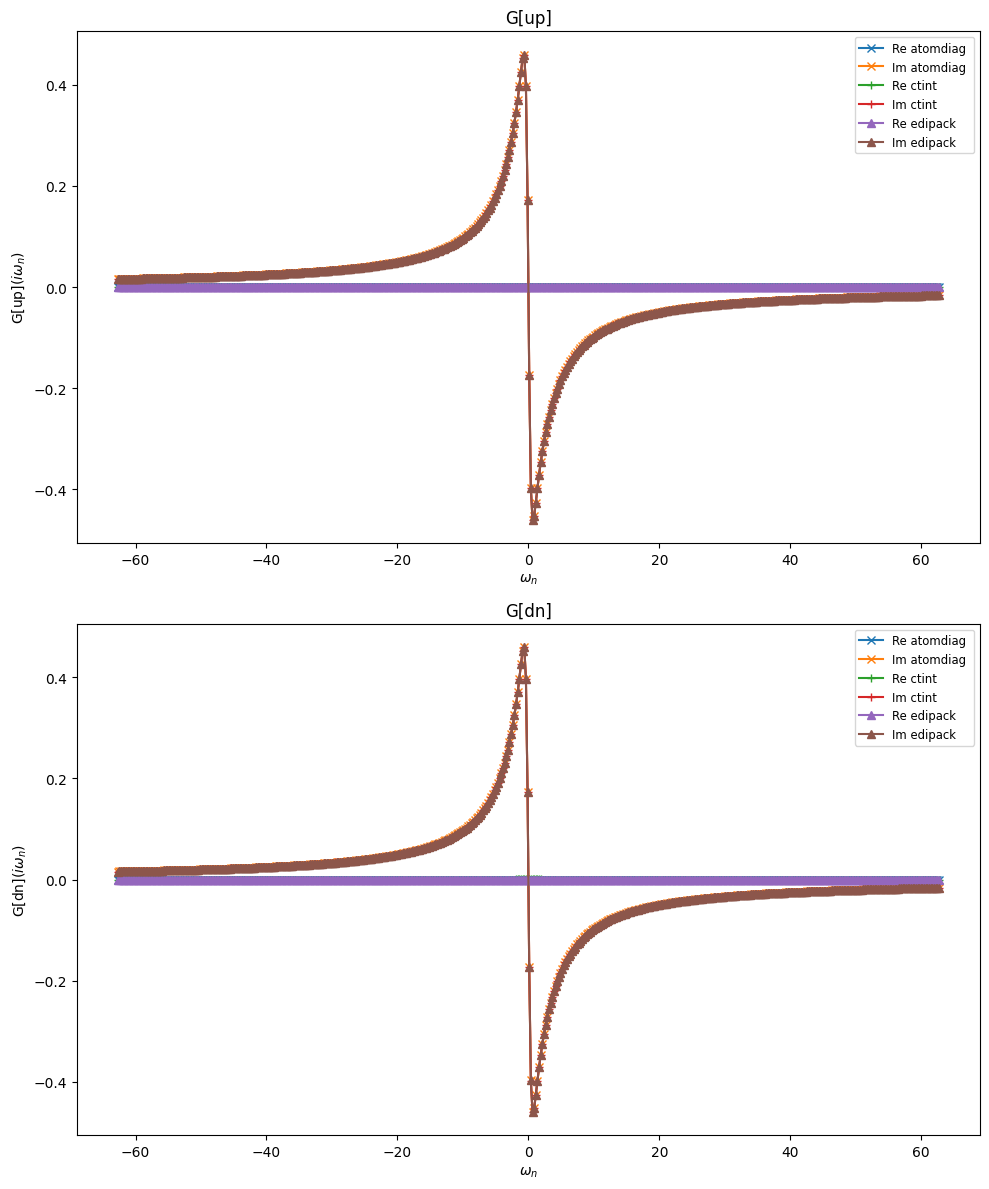

In [3]:
G_dict = {s: d['G'] for s, d in data.items() if 'G' in d}
if G_dict:
    plot_iw_comparison(G_dict, 'G', block_lst)
    deviation_table(G_dict, block_lst, label='G')

## 2. Self-Energy $\Sigma(i\omega_n)$


  Sigma max-norm deviations:
              atomdiag     ctint   edipack
    atomdiag            1.53e-02  7.49e-09
       ctint                      1.53e-02
     edipack                              


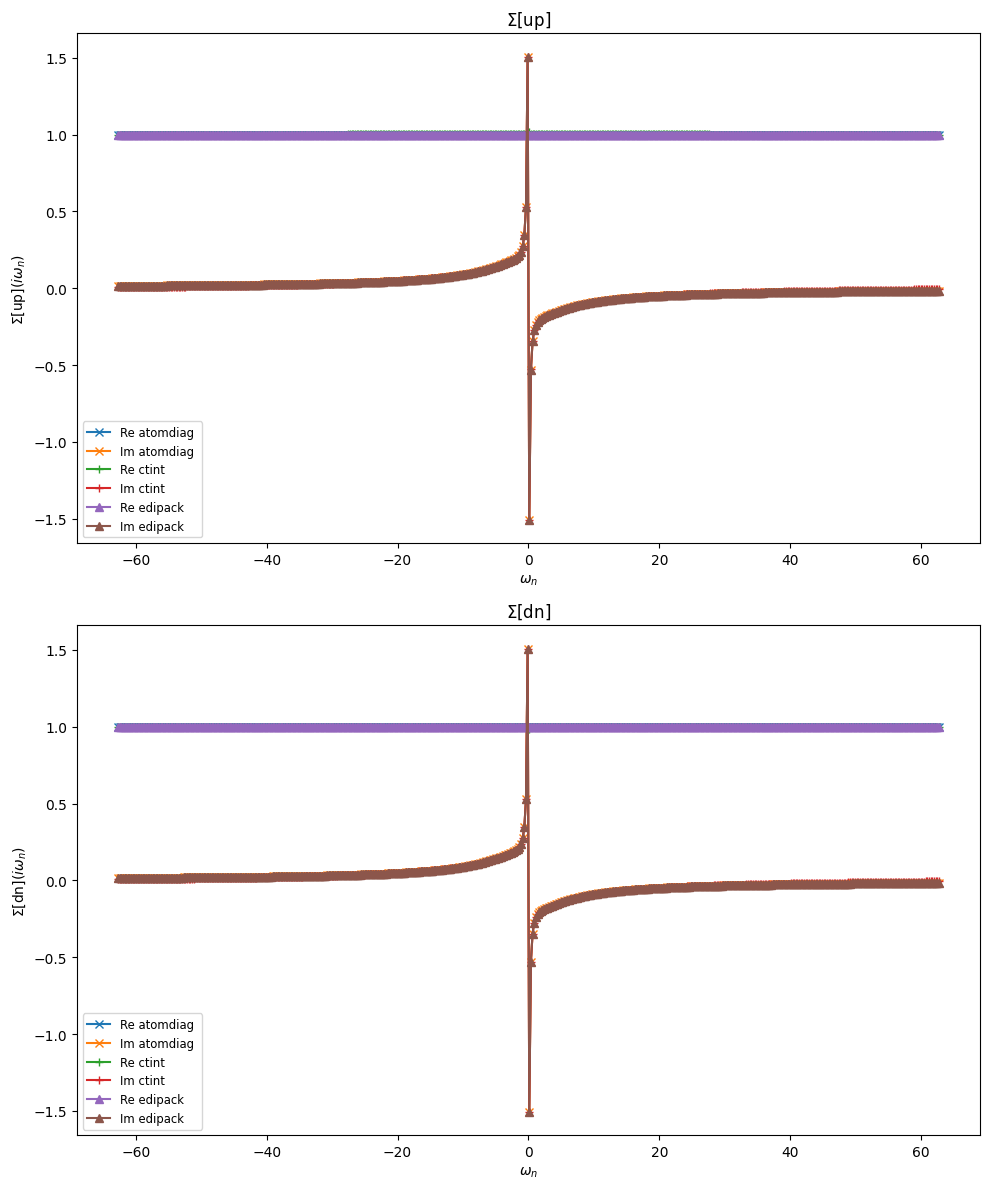

In [4]:
Sigma_dict = compute_sigma(data, G0_iw)
if Sigma_dict:
    plot_iw_comparison(Sigma_dict, r'$\Sigma$', block_lst)
    deviation_table(Sigma_dict, block_lst, label='Sigma')

## 3. Static Observables

In [5]:
plot_static_obs_table(data, 'density')
plot_static_obs_table(data, 'nn_ab')


  density:
    atomdiag              dn_0: 0.500000, dn_1: 0.500000, dn_2: 0.500000, dn_3: 0.500000, up_0: 0.500000, up_1: 0.500000, up_2: 0.500000, up_3: 0.500000
    ctint                 dn_0: 0.500127, dn_1: 0.499898, dn_2: 0.499908, dn_3: 0.500212, up_0: 0.499873, up_1: 0.500102, up_2: 0.500092, up_3: 0.499788
    edipack               dn_0: 0.500000, dn_1: 0.500000, dn_2: 0.500000, dn_3: 0.500000, up_0: 0.500000, up_1: 0.500000, up_2: 0.500000, up_3: 0.500000

  nn_ab:
    atomdiag              dn_0,dn_0: 0.500000, dn_0,dn_1: 0.112086, dn_0,dn_2: 0.112086, dn_0,dn_3: 0.288876, dn_0,up_0: 0.115199, dn_0,up_1: 0.339401, dn_0,up_2: 0.339401, dn_0,up_3: 0.192951, dn_1,dn_0: 0.112086, dn_1,dn_1: 0.500000, dn_1,dn_2: 0.288876, dn_1,dn_3: 0.112086, dn_1,up_0: 0.339401, dn_1,up_1: 0.115199, dn_1,up_2: 0.192951, dn_1,up_3: 0.339401, dn_2,dn_0: 0.112086, dn_2,dn_1: 0.288876, dn_2,dn_2: 0.500000, dn_2,dn_3: 0.112086, dn_2,up_0: 0.339401, dn_2,up_1: 0.192951, dn_2,up_2: 0.115199, dn_2,up_3:

## 4. Real-Frequency Spectral Function $A(\omega)$

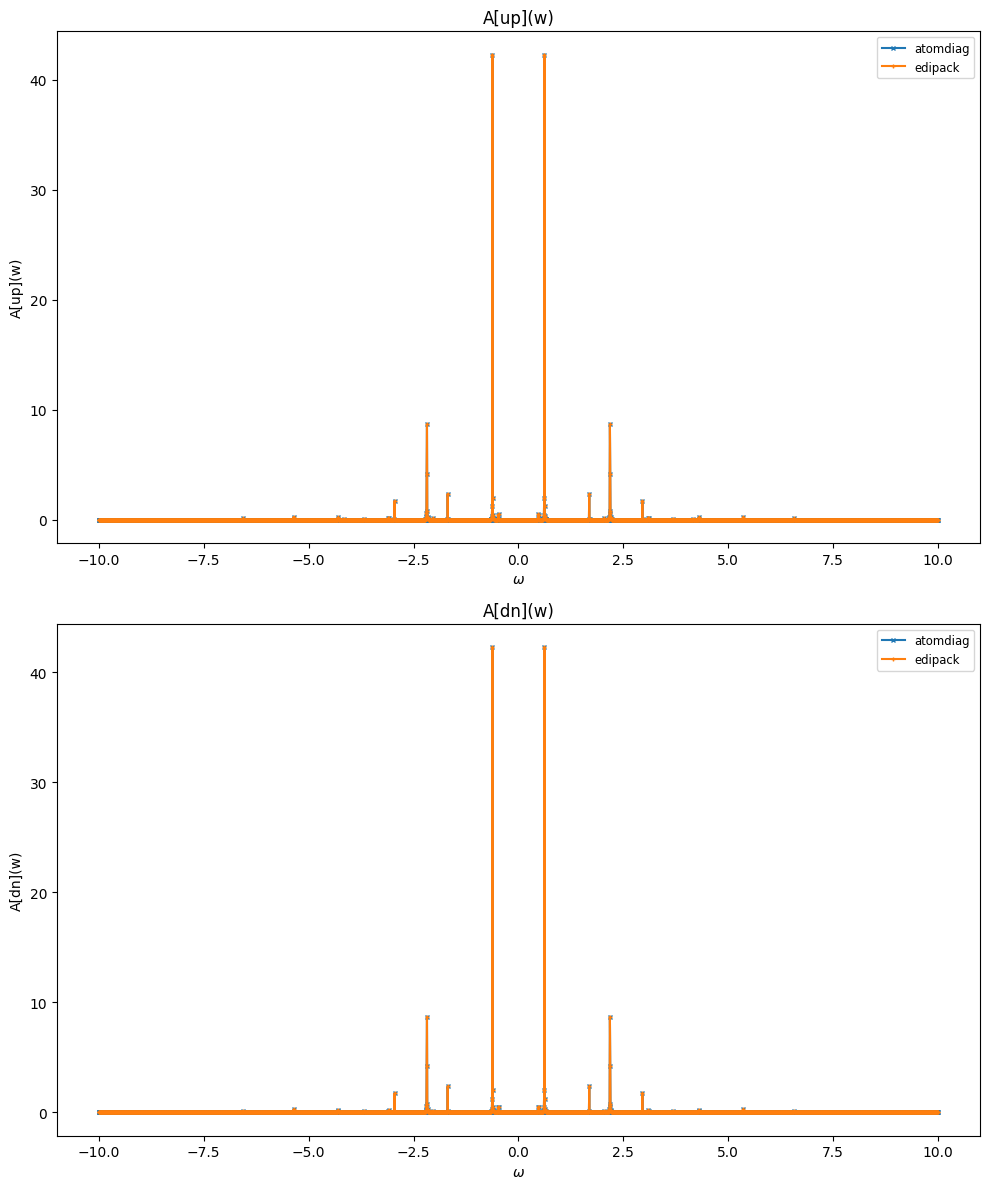

In [6]:
G_w_dict = {s: d['G_w'] for s, d in data.items() if 'G_w' in d}
if G_w_dict:
    plot_w_comparison(G_w_dict, 'G_w', block_lst, spectral=True)
else:
    print("No solver has real-frequency data.")

## 5. Three-Point Correlator $\chi_3$

In [7]:
for ch in ['d', 'm', 's', 't']:
    key = f'chi3_{ch}'
    chi3 = {s: d[key] for s, d in data.items() if key in d}
    if chi3:
        plot_chi_contour(chi3, ch)

## 6. Two-Particle Green Function $\chi_4$ / $G_{2c}$

In [8]:
for ch in ['d', 'm', 's', 't']:
    key = f'chi4_{ch}'
    chi4 = {s: d[key] for s, d in data.items() if key in d}
    if chi4:
        plot_chi_contour(chi4, ch)